## My first EDA

In [4]:
# importing python libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# import dataset csv file 
data=pd.read_csv('shopify_sales_dataset_ml_eda.csv')

In [7]:
data.head()

,order_id,order_date,customer_id,product_id,product_category,product_price,discount_percent,quantity,customer_country,traffic_source,payment_method,shipping_cost,rating,is_returned,discounted_price,revenue,profit
0,1,2023-04-13,14958,7824,Accessories,143.39,40,1,USA,Paid Ads,Credit Card,21.08,2.0,0,86.03,86.03,64.95
1,2,2024-03-11,26825,5557,Sports,746.49,15,4,UAE,Email,PayPal,5.48,3.7,0,634.52,2538.08,2532.60
2,3,2025-05-10,37450,2225,Electronics,641.06,5,5,Canada,Paid Ads,Apple Pay,11.27,3.2,0,609.01,3045.05,3033.78
3,4,2023-09-28,20691,7855,Footwear,512.39,0,3,UAE,Direct,Apple Pay,19.22,1.1,0,512.39,1537.17,1517.95
4,5,2023-04-17,24631,7789,Sports,415.89,25,3,UAE,Social Media,Debit Card,24.94,4.1,0,311.92,935.76,910.82


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          60000 non-null  int64  
 1   order_date        60000 non-null  object 
 2   customer_id       60000 non-null  int64  
 3   product_id        60000 non-null  int64  
 4   product_category  60000 non-null  object 
 5   product_price     60000 non-null  float64
 6   discount_percent  60000 non-null  int64  
 7   quantity          60000 non-null  int64  
 8   customer_country  60000 non-null  object 
 9   traffic_source    60000 non-null  object 
 10  payment_method    60000 non-null  object 
 11  shipping_cost     60000 non-null  float64
 12  rating            60000 non-null  float64
 13  is_returned       60000 non-null  int64  
 14  discounted_price  60000 non-null  float64
 15  revenue           60000 non-null  float64
 16  profit            60000 non-null  float6

In [9]:
## Checking null values in the dataset 
data.isnull().sum()

for col in data.columns:
    null_count = data[col].isnull().sum()
    if null_count > 0:
        print(f"{col}: {null_count}")
else:
    print('no null value')


no null value


In [10]:
## this function only use for int ,float tupe columns
data.describe()

,order_id,customer_id,product_id,product_price,discount_percent,quantity,shipping_cost,rating,is_returned,discounted_price,revenue,profit
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,30000.500000,30035.075600,4504.738650,403.427068,18.151500,3.009567,13.521758,3.002440,0.148117,330.220212,994.098926,980.577168
std,17320.652413,11540.753215,2018.287018,230.045257,12.527663,1.414794,6.627934,1.152265,0.355219,197.114822,806.445785,806.508355
min,1.000000,10000.000000,1000.000000,5.010000,0.000000,1.000000,2.000000,1.000000,0.000000,3.080000,3.080000,-20.490000
25%,15000.750000,20037.750000,2751.750000,203.160000,5.000000,2.000000,7.760000,2.000000,0.000000,161.957500,355.620000,341.925000
50%,30000.500000,30079.000000,4503.500000,403.855000,20.000000,3.000000,13.580000,3.000000,0.000000,322.560000,760.470000,747.275000
75%,45000.250000,40036.250000,6257.000000,603.135000,30.000000,4.000000,19.230000,4.000000,0.000000,482.242500,1462.450000,1449.807500
max,60000.000000,49999.000000,7999.000000,799.990000,40.000000,5.000000,25.000000,5.000000,1.000000,799.900000,3999.500000,3989.950000


## Checking if nay duplicate value in the dataset 

In [11]:

# check duplicate value for each column
for col in data.columns:
    dup_count = data[col].duplicated().sum()

    if dup_count:
        print(f"Duplicate values in {col}: {dup_count}")
    else:
        print(f"No duplicate values in {col}")

      

No duplicate values in order_id
Duplicate values in order_date: 59100
Duplicate values in customer_id: 28846
Duplicate values in product_id: 53002
Duplicate values in product_category: 59993
Duplicate values in product_price: 17957
Duplicate values in discount_percent: 59992
Duplicate values in quantity: 59995
Duplicate values in customer_country: 59993
Duplicate values in traffic_source: 59995
Duplicate values in payment_method: 59995
Duplicate values in shipping_cost: 57699
Duplicate values in rating: 59959
Duplicate values in is_returned: 59998
Duplicate values in discounted_price: 19772
Duplicate values in revenue: 10039
Duplicate values in profit: 7520


## this is an e-commerec data set so it shoudl be ok to have duplicates value in these columns

In [12]:
## Is_returned column value should be yes or NO instead of o and 1
## so first change the data type of the column and then update the value 
data['is_returned']=data['is_returned'].astype('object')

In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          60000 non-null  int64  
 1   order_date        60000 non-null  object 
 2   customer_id       60000 non-null  int64  
 3   product_id        60000 non-null  int64  
 4   product_category  60000 non-null  object 
 5   product_price     60000 non-null  float64
 6   discount_percent  60000 non-null  int64  
 7   quantity          60000 non-null  int64  
 8   customer_country  60000 non-null  object 
 9   traffic_source    60000 non-null  object 
 10  payment_method    60000 non-null  object 
 11  shipping_cost     60000 non-null  float64
 12  rating            60000 non-null  float64
 13  is_returned       60000 non-null  object 
 14  discounted_price  60000 non-null  float64
 15  revenue           60000 non-null  float64
 16  profit            60000 non-null  float6

# update the 0 =no and 1=yes 
## Using map function for the update

In [13]:
data['is_returned']=data['is_returned'].map({1:'yes',0:'no'})

In [14]:
data.head(20)

,order_id,order_date,customer_id,product_id,product_category,product_price,discount_percent,quantity,customer_country,traffic_source,payment_method,shipping_cost,rating,is_returned,discounted_price,revenue,profit
0,1,2023-04-13,14958,7824,Accessories,143.39,40,1,USA,Paid Ads,Credit Card,21.08,2.0,no,86.03,86.03,64.95
1,2,2024-03-11,26825,5557,Sports,746.49,15,4,UAE,Email,PayPal,5.48,3.7,no,634.52,2538.08,2532.60
2,3,2025-05-10,37450,2225,Electronics,641.06,5,5,Canada,Paid Ads,Apple Pay,11.27,3.2,no,609.01,3045.05,3033.78
3,4,2023-09-28,20691,7855,Footwear,512.39,0,3,UAE,Direct,Apple Pay,19.22,1.1,no,512.39,1537.17,1517.95
4,5,2023-04-17,24631,7789,Sports,415.89,25,3,UAE,Social Media,Debit Card,24.94,4.1,no,311.92,935.76,910.82
5,6,2023-03-13,29596,2796,Beauty,444.14,0,5,UAE,Social Media,Apple Pay,20.29,2.6,no,444.14,2220.70,2200.41
6,7,2024-12-01,11896,6012,Accessories,244.18,15,1,Canada,Social Media,Debit Card,23.91,1.4,no,207.55,207.55,183.64
7,8,2023-01-21,43857,4248,Beauty,457.16,25,1,USA,Email,Apple Pay,4.17,3.0,no,342.87,342.87,338.70
8,9,2024-09-06,10308,3966,Fashion,394.28,15,1,India,Direct,Cash on Delivery,18.09,4.9,no,335.14,335.14,317.05
9,10,2023-05-02,35168,7180,Electronics,363.69,30,2,UAE,Social Media,Apple Pay,23.80,2.4,yes,254.58,509.16,485.36


## Analyzing the data 

C:\Users\Rajat.Das\AppData\Local\Temp\ipykernel_10920\3454728534.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values,palette='viridis')


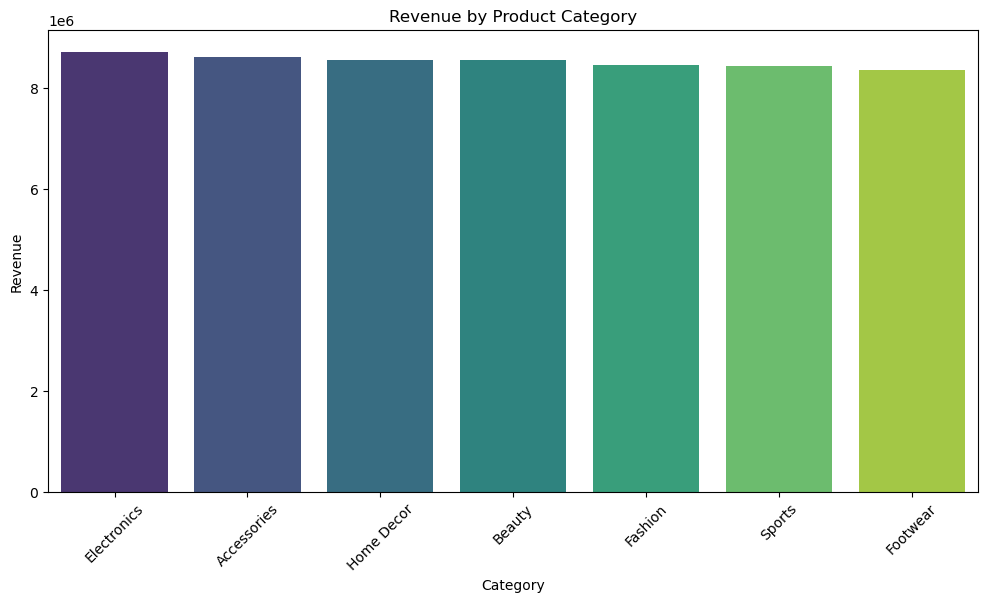

In [15]:
##TOP PRODUCT CATEGORIES (BAR CHART)

category_sales = data.groupby('product_category')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=category_sales.index, y=category_sales.values,palette='viridis')
plt.xticks(rotation=45)
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

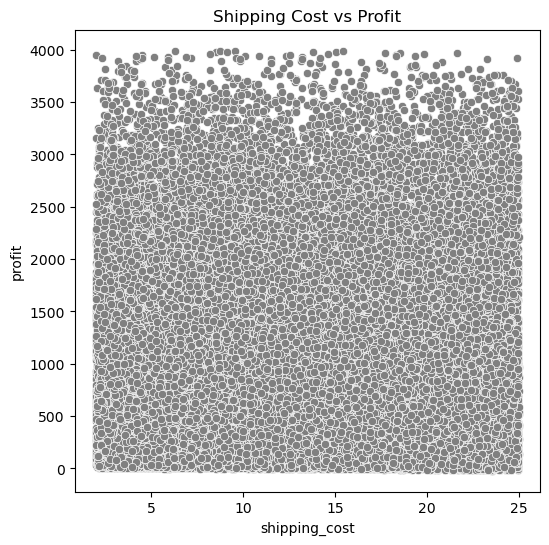

In [17]:
##Shipping cost vs profit
plt.figure(figsize=(6,6))
sns.scatterplot(data=data, x='shipping_cost', y='profit', color='gray')
plt.title("Shipping Cost vs Profit")
plt.show()

C:\Users\Rajat.Das\AppData\Local\Temp\ipykernel_10920\2100424262.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Country_rev.index, y=Country_rev.values,palette='viridis')


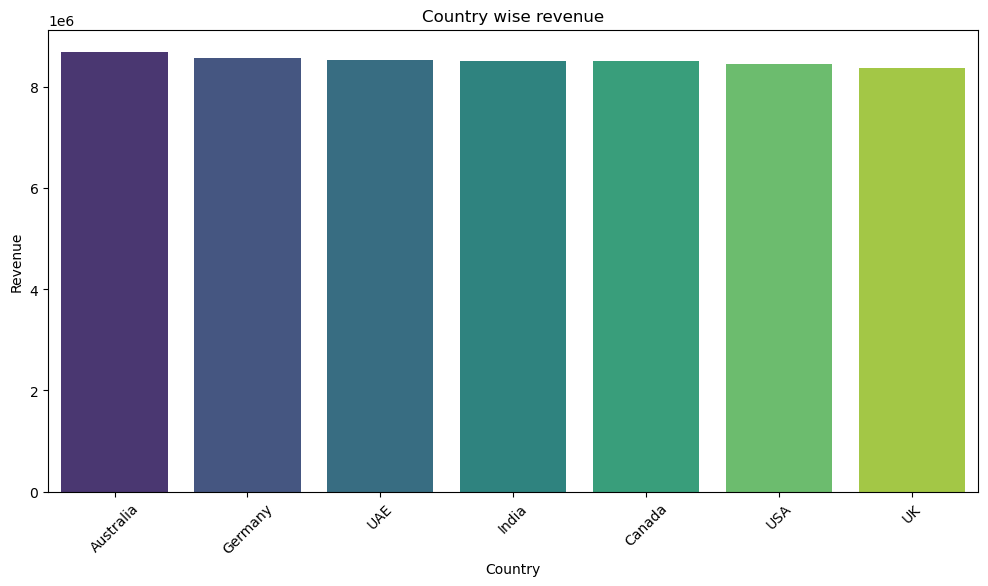

In [18]:
Country_rev= data.groupby('customer_country')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=Country_rev.index, y=Country_rev.values,palette='viridis')
plt.xticks(rotation=45)
plt.title("Country wise revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()

In [24]:
#Count of the unique customer id
data['customer_id'].nunique()

31154

C:\Users\Rajat.Das\AppData\Local\Temp\ipykernel_10920\2126578763.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cust_rev.index, y=cust_rev.values,palette='viridis')


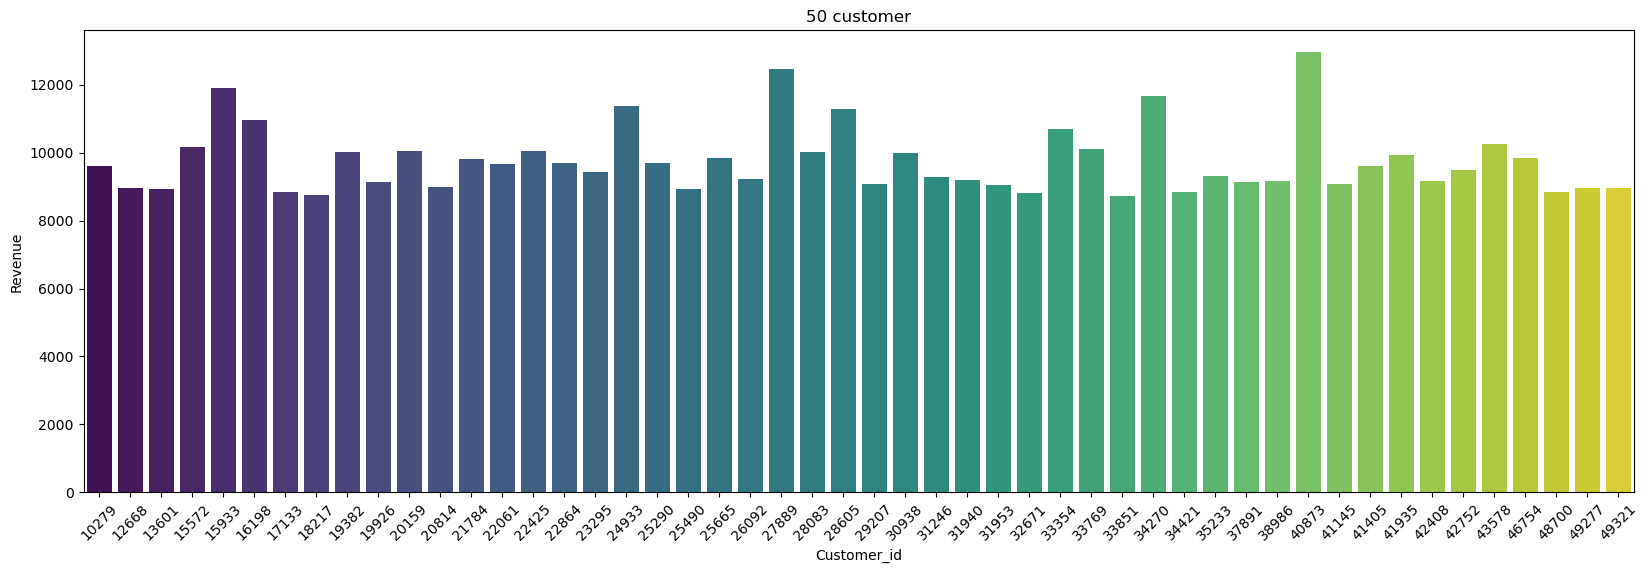

In [26]:
## top 50 customer revenue 
cust_rev=data.groupby('customer_id')['revenue'].sum().sort_values(ascending=False).head(50)
plt.figure(figsize=(20,6))
sns.barplot(x=cust_rev.index, y=cust_rev.values,palette='viridis')
plt.xticks(rotation=45)
plt.title("50 customer")
plt.xlabel("Customer_id")
plt.ylabel("Revenue")
plt.show()


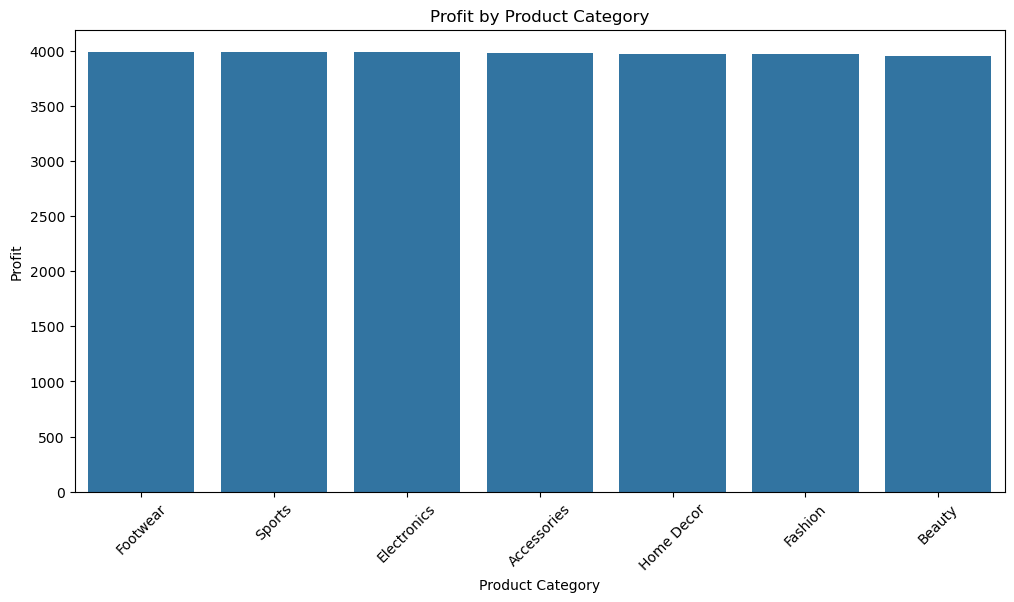

In [48]:
## product vs Profit plot

profit_by_category = (
    data.groupby('product_category')['profit']
        .max()
        .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=profit_by_category.index,
    y=profit_by_category.values
)

plt.xticks(rotation=45)
plt.title("Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Profit")
plt.show()

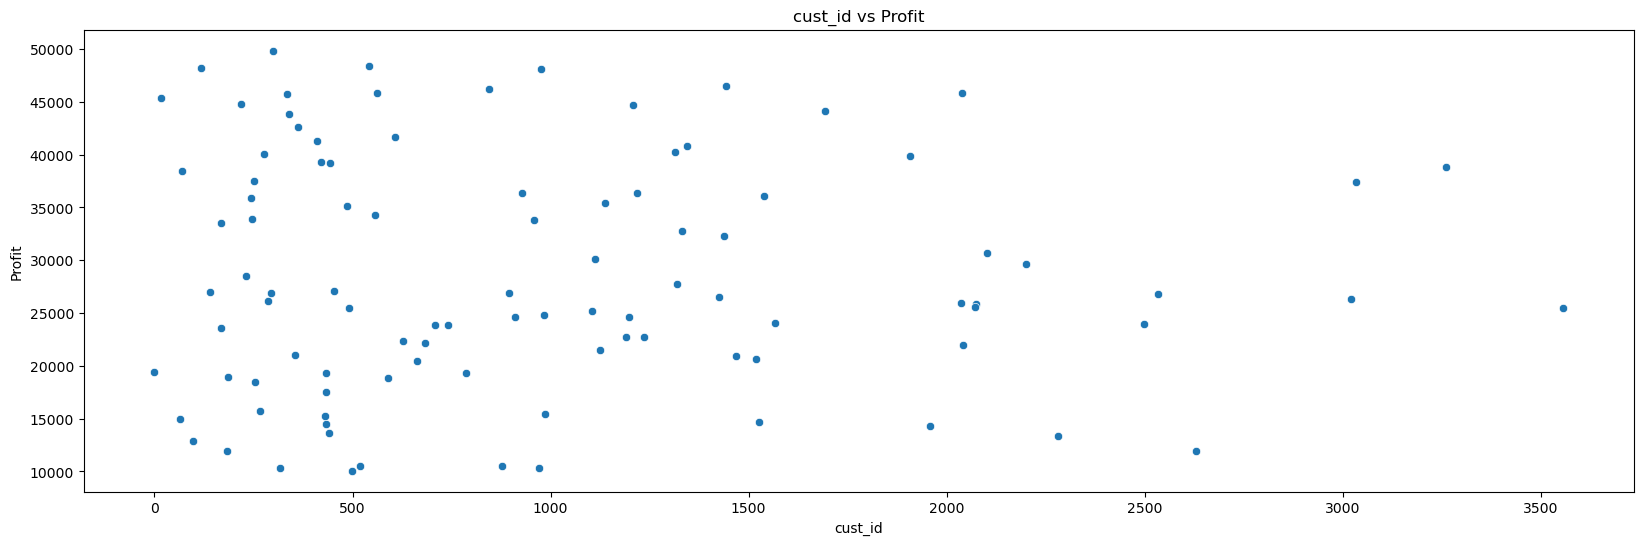

In [51]:
## top 100 customer vs profit
data100=data.head(100)
plt.figure(figsize=(20,6))
sns.scatterplot(data=data100,y='customer_id',x='profit')

plt.title("cust_id vs Profit")
plt.xlabel("cust_id")
plt.ylabel("Profit")
plt.show()



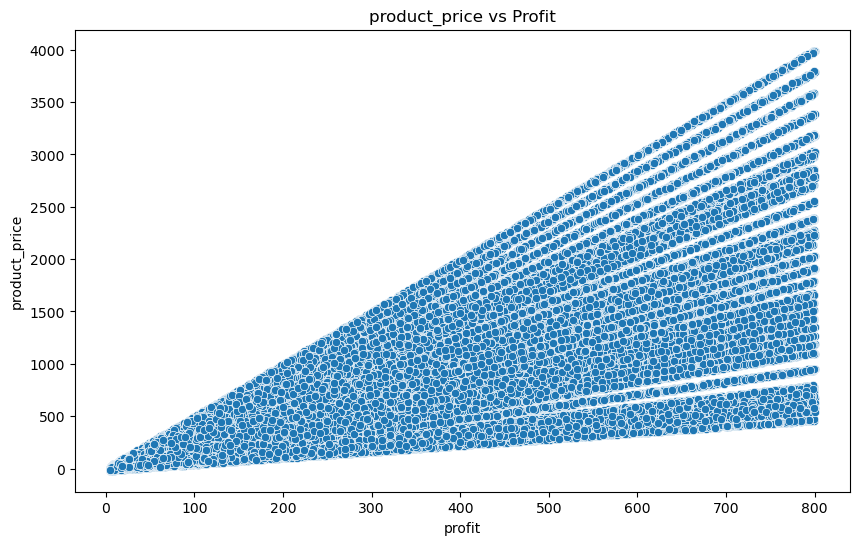

In [53]:

plt.figure(figsize=(10,6))
sns.scatterplot(data=data,y='profit',x='product_price')

plt.title("product_price vs Profit")
plt.xlabel("profit")
plt.ylabel("product_price")
plt.show()

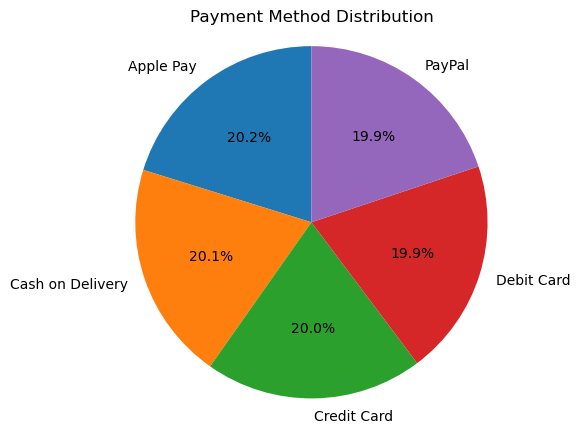

In [56]:
#Payment method analysis
payment_counts = data['payment_method'].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct='%1.1f%%',startangle=90
)
plt.axis('equal')
plt.title("Payment Method Distribution")
plt.show()

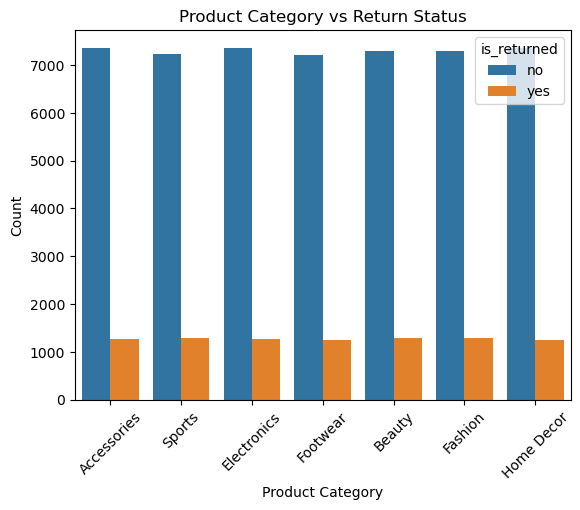

In [57]:
## Prodct vs returned analysis
sns.countplot(
    data=data,
    x='product_category',
    hue='is_returned'
)

plt.xticks(rotation=45)
plt.title("Product Category vs Return Status")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.show()